# Heat Vulnerability Analysis — Amsterdam

**Purpose:** Produce a policy-maker oriented heat vulnerability map for Amsterdam, identifying which neighborhoods need intervention most urgently.

## Analytical pipeline

```
Klimaatrisicokaarten GDB (HI scores + geometry)
        +
CBS PC6 2024 (pc6 polygons → spatial join → buurt aggregation)
        +
ams_features.csv (distance-to-facility + NDVI + water — not in CBS PC6)
        ↓
PCA → Social Vulnerability Index (SVI)
        +
Cooling Access Score
        ↓
Heat Vulnerability Index (HVI) = 40% heat + 40% SVI + 20% cooling gap
        ↓
Gap Analysis → LISA → Priority Ranking → GeoJSON export
```

## Data sources
- **Klimaatrisicokaarten GDB** (`Risicokaarten definitief.gdb`): Structured risk scores + buurt polygons for 498 Amsterdam buurten. Scores for heat exposure (PET temperature, shadow, population pressure), sensitivity (65+, chronically ill, low income), and adaptive capacity (garden access).
- **CBS PC6 2024** (`cbs_pc6_2024_v1.gpkg`): Official Statistics Netherlands data at 6-digit postcode level, reference date 1 January 2024. 465k postcodes nationwide. Spatially joined to RK buurt boundaries and population-weighted to buurt level. Provides demographics and housing variables.
- **ams_features.csv**: Distance-to-facility variables (library, pool, train station) from CBS Kerncijfers and satellite-derived variables (NDVI, surface water %, surface temperature from Google Earth Engine). Used for cooling access score only — these variables are not present in the CBS PC6 dataset.

## Methods summary
1. **Spatial aggregation** — CBS PC6 centroid-in-polygon join to RK buurten; count variables summed, percentage variables population-weighted
2. **PCA** — data-driven weights for CBS social vulnerability indicators
3. **Cooling access score** — composite from CBS distance-to-amenity + environmental variables
4. **Enhanced HVI** — 40% physical heat (HI_TOTAAL_S) + 40% PCA social score + 20% cooling access gap
5. **Gap analysis** — cross-tabulate vulnerability tier × access tier
6. **LISA spatial autocorrelation** — statistically significant hotspot clusters via Moran's I
7. **Priority ranking** — top neighbourhoods by combined score
8. **GeoJSON export** — all scores attached to geometry, ready for front-end map

## 0. Setup

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Spatial stats — install if missing: pip install esda libpysal
try:
    import esda
    import libpysal
    SPATIAL_STATS = True
except ImportError:
    print("esda/libpysal not found. Run: pip install esda libpysal")
    SPATIAL_STATS = False

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
print("Setup complete")

Setup complete


## 1. Load & join data

Three sources:
- **Klimaatrisicokaarten GDB** — heat risk scores + buurt geometry (498 buurten)
- **CBS PC6 2024** — demographics at postcode level, spatially aggregated to buurt
- **ams_features.csv** — distance-to-facility and satellite-derived environmental variables (fallback for variables not in CBS PC6)

In [ ]:
# --- Klimaatrisicokaarten + geometry from the same GDB ---
gdf_rk = gpd.read_file(
    'charlie/Klimaatrisicokaarten/Risicokaarten definitief.gdb',
    layer='Risico_per_buurt_20231009'
)
gdf_rk['buurtnaam'] = gdf_rk['NAME'].str.replace('RK_', '', regex=False).str.strip()
hi_cols = [c for c in gdf_rk.columns if c.startswith('HI_')]
rk = gdf_rk[['buurtnaam', 'geometry'] + hi_cols].copy()
if rk.crs and rk.crs.to_epsg() != 4326:
    rk = rk.to_crs(epsg=4326)
print(f"Klimaatrisicokaarten + geometry: {len(rk)} buurten, {len(hi_cols)} HI columns")

# --- CBS PC6 2024 ---
# Sentinel values: -99997 = confidential (too few obs), -99995 = not applicable
CBS_PC6_PATH = 'charlie/2025-cbs_pc6_2024_v1 (1)/cbs_pc6_2024_v1.gpkg'
cbs_pc6_raw = gpd.read_file(CBS_PC6_PATH, layer='cbs_pc6_2024')
cbs_pc6_raw = cbs_pc6_raw.replace({-99997: np.nan, -99995: np.nan})
print(f"CBS PC6 2024: {len(cbs_pc6_raw)} postcodes loaded (nationwide)")

# --- Distance + environmental variables from ams_features ---
# CBS PC6 distance-to-facility columns are not populated (all -99995).
# We use ams_features.csv for: library/pool/train distances, NDVI, water %.
DIST_COLS = [
    'buurtnaam',
    'bibliotheekGemiddeldeAfstandInKm',
    'zwembadGemiddeldeAfstandInKm',
    'treinstationGemiddeldeAfstandInKm',
    'ndvi_mean',
    'water_prc',
]
ams_dist = pd.read_csv('charlie/ams_features.csv')[DIST_COLS].copy()
ams_dist['buurtnaam'] = ams_dist['buurtnaam'].str.replace('-', ' ').str.strip()
ams_dist = ams_dist.dropna(subset=['buurtnaam'])
print(f"Distance/environmental data: {len(ams_dist)} buurten from ams_features.csv")

In [3]:
## Aggregate CBS PC6 → buurt level via spatial join

# Reproject CBS to match RK (EPSG:28992)
rk_proj = rk.to_crs(epsg=28992)
cbs_pc6 = cbs_pc6_raw.copy()  # already in EPSG:28992

# PC6 centroids for point-in-polygon join (fast, avoids boundary ambiguity)
cbs_centroids = cbs_pc6.copy()
cbs_centroids.geometry = cbs_pc6.centroid

COUNT_COLS = [
    'aantal_inwoners',
    'aantal_inwoners_65_jaar_en_ouder',
    'aantal_eenpersoonshuishoudens',
    'aantal_part_huishoudens',
    'aantal_personen_met_uitkering_onder_aowlft',
]
PCT_COLS = [
    'percentage_geb_buiten_nederland_herkmst_buiten_europa',
    'percentage_geb_nederland_herkomst_buiten_europa',
]

# Spatial join
pc6_in_buurt = gpd.sjoin(
    cbs_centroids[COUNT_COLS + PCT_COLS + ['geometry']],
    rk_proj[['buurtnaam', 'geometry']],
    how='inner', predicate='within'
).drop(columns=['geometry', 'index_right'])

print(f"PC6 matched to Amsterdam buurten: {len(pc6_in_buurt)}, covering {pc6_in_buurt['buurtnaam'].nunique()} buurten")

# Aggregate counts: sum
count_agg = pc6_in_buurt.groupby('buurtnaam')[COUNT_COLS].sum(min_count=1).reset_index()

# Aggregate percentages: population-weighted mean
def pop_wm(group, col):
    mask = group[col].notna() & group['aantal_inwoners'].notna()
    if not mask.any(): return float('nan')
    w = group.loc[mask, 'aantal_inwoners']
    return (group.loc[mask, col] * w).sum() / w.sum() if w.sum() > 0 else float('nan')

pct_agg = pc6_in_buurt.groupby('buurtnaam').apply(
    lambda g: pd.Series({col: pop_wm(g, col) for col in PCT_COLS})
).reset_index()

cbs = count_agg.merge(pct_agg, on='buurtnaam', how='outer')

# Derive percentage variables from counts
pop = cbs['aantal_inwoners'].replace(0, float('nan'))
hh  = cbs['aantal_part_huishoudens'].replace(0, float('nan'))
cbs['pct_65plus']         = cbs['aantal_inwoners_65_jaar_en_ouder'] / pop * 100
cbs['pct_eenpersoons_hh'] = cbs['aantal_eenpersoonshuishoudens'] / hh * 100
cbs['pct_uitkering']      = cbs['aantal_personen_met_uitkering_onder_aowlft'] / pop * 100
cbs['pct_niet_westers']   = (
    cbs['percentage_geb_buiten_nederland_herkmst_buiten_europa'].fillna(0) +
    cbs['percentage_geb_nederland_herkomst_buiten_europa'].fillna(0)
)
both_nan = cbs['percentage_geb_buiten_nederland_herkmst_buiten_europa'].isna() & cbs['percentage_geb_nederland_herkomst_buiten_europa'].isna()
cbs.loc[both_nan, 'pct_niet_westers'] = float('nan')

print(f"Aggregated to {len(cbs)} buurten")
print(cbs[['buurtnaam','pct_65plus','pct_eenpersoons_hh','pct_uitkering','pct_niet_westers']].dropna().head(5).round(1).to_string(index=False))

PC6 matched to Amsterdam buurten: 19171, covering 495 buurten


Aggregated to 495 buurten
                buurtnaam  pct_65plus  pct_eenpersoons_hh  pct_uitkering  pct_niet_westers
    Aalsmeerwegbuurt Oost         7.3                56.2            3.1              25.2
    Aalsmeerwegbuurt West         3.9                51.6            1.9              29.2
           Aetsveld Noord        22.0                13.5            1.6              31.6
            Aetsveld Zuid        23.1                24.2            1.7              35.5
Amstel III deel A/B Noord         0.5                60.3            0.5              72.4


In [4]:
from difflib import get_close_matches

# RK → CBS: buurtnaam already aligned (CBS came from RK spatial join), so direct left join
gdf_joined = rk.merge(cbs, on='buurtnaam', how='left')
cbs_matched = gdf_joined['pct_65plus'].notna().sum()
print(f"RK + CBS: {len(gdf_joined)} polygons, {cbs_matched} with CBS demographic data")

# Merge distance/environmental variables from ams_features
# These have old-format names — fuzzy match to RK buurt names
rk_names   = list(rk['buurtnaam'].unique())
dist_names = list(ams_dist['buurtnaam'].dropna().unique())

exact = {n: n for n in rk_names if n in dist_names}
fuzzy = {}
for name in [n for n in rk_names if n not in exact]:
    cands = get_close_matches(name, dist_names, n=1, cutoff=0.82)
    if cands: fuzzy[name] = cands[0]

print(f"Distance match — exact: {len(exact)}, fuzzy: {len(fuzzy)}, unmatched: {len(rk_names)-len(exact)-len(fuzzy)}")

name_map = {**exact, **fuzzy}
ams_dist_mapped = ams_dist.copy()
ams_dist_mapped['buurtnaam'] = ams_dist_mapped['buurtnaam'].map({v:k for k,v in name_map.items()}).fillna(ams_dist_mapped['buurtnaam'])

gdf_joined = gdf_joined.merge(ams_dist_mapped, on='buurtnaam', how='left')
dist_matched = gdf_joined['bibliotheekGemiddeldeAfstandInKm'].notna().sum()
print(f"Distance/environmental data matched: {dist_matched} buurten")

# Reproject to WGS84
if gdf_joined.crs and gdf_joined.crs.to_epsg() != 4326:
    gdf_joined = gdf_joined.to_crs(epsg=4326)

joined = pd.DataFrame(gdf_joined.drop(columns='geometry'))
print(f"\nFinal dataset: {len(joined)} buurten, {len(joined.columns)} columns")

RK + CBS: 498 polygons, 449 with CBS demographic data
Distance match — exact: 437, fuzzy: 39, unmatched: 22
Distance/environmental data matched: 476 buurten

Final dataset: 498 buurten, 63 columns


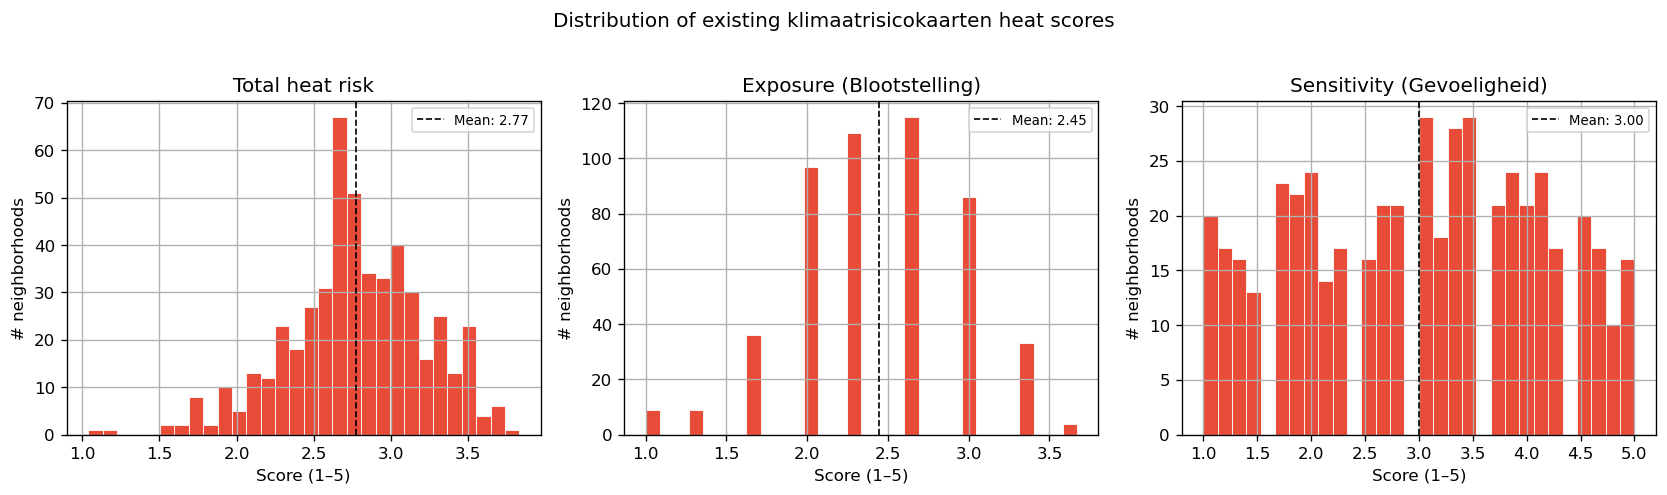

In [5]:
# Quick overview: existing heat risk score distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, title in zip(axes,
    ['HI_TOTAAL_S', 'HI_BLOOTSTELLING_S', 'HI_GEVOELIGHEID_S'],
    ['Total heat risk', 'Exposure (Blootstelling)', 'Sensitivity (Gevoeligheid)']):
    if col in joined.columns:
        joined[col].dropna().hist(bins=30, ax=ax, color='#E84B37', edgecolor='white', linewidth=0.5)
        ax.set_title(title)
        ax.set_xlabel('Score (1–5)')
        ax.set_ylabel('# neighborhoods')
        ax.axvline(joined[col].mean(), color='black', linestyle='--', linewidth=1, label=f'Mean: {joined[col].mean():.2f}')
        ax.legend(fontsize=8)

plt.suptitle('Distribution of existing klimaatrisicokaarten heat scores', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('output_01_existing_scores_dist.png', bbox_inches='tight')
plt.show()

## 2. PCA-based Social Vulnerability Index (CBS PC6 2024)

We compute a Social Vulnerability Index using four variables derived from CBS PC6 2024, aggregated to buurt level:
- **% single-person households** — social isolation proxy (no one to check on them)
- **% welfare recipients under AOW age** — low income proxy
- **% 65+ residents** — elderly vulnerability
- **% non-western background** — language barrier proxy affecting heat warning uptake

PCA extracts data-driven weights rather than arbitrary manual ones.

In [6]:
# Social vulnerability features for PCA — derived from CBS PC6 2024 spatial aggregation
# Variables computed from counts (more reliable than pre-aggregated percentages)
SVI_FEATURES = [
    'pct_eenpersoons_hh',   # % single-person households — social isolation proxy
    'pct_uitkering',        # % welfare recipients under AOW age — low income proxy
    'pct_65plus',           # % 65+ residents — elderly vulnerability
    'pct_niet_westers',     # % non-western background — language barrier proxy
]

# Note: WMO clients and social minimum households are not available in CBS PC6.
# These were present in the old ams_features.csv (CBS Kerncijfers buurt level).
# The current set captures the key dimensions of heat vulnerability from the literature.

svi_available = [c for c in SVI_FEATURES if c in joined.columns]
print(f"Using {len(svi_available)}/{len(SVI_FEATURES)} SVI features:")
for c in svi_available:
    print(f"  {c}: {joined[c].notna().sum()} non-null values, mean={joined[c].mean():.1f}")

svi_df = joined[['buurtnaam'] + svi_available].copy()
svi_df = svi_df.dropna(subset=svi_available, thresh=len(svi_available) - 1)
print(f"\n{len(svi_df)} neighborhoods with sufficient SVI data")

Using 4/4 SVI features:
  pct_eenpersoons_hh: 461 non-null values, mean=52.5
  pct_uitkering: 398 non-null values, mean=7.4
  pct_65plus: 449 non-null values, mean=12.5
  pct_niet_westers: 447 non-null values, mean=43.5

444 neighborhoods with sufficient SVI data


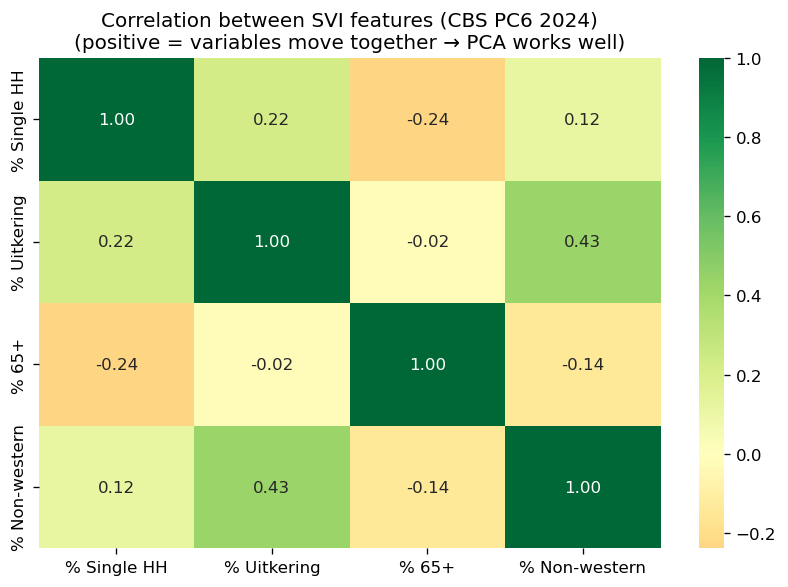

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
corr = svi_df[svi_available].corr()
short_names = {
    'pct_eenpersoons_hh': '% Single HH',
    'pct_uitkering':      '% Uitkering',
    'pct_65plus':         '% 65+',
    'pct_niet_westers':   '% Non-western',
}
labels = [short_names.get(c, c) for c in svi_available]
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title('Correlation between SVI features (CBS PC6 2024)\n(positive = variables move together → PCA works well)')
plt.tight_layout()
plt.savefig('output_02_svi_correlation.png', bbox_inches='tight')
plt.show()

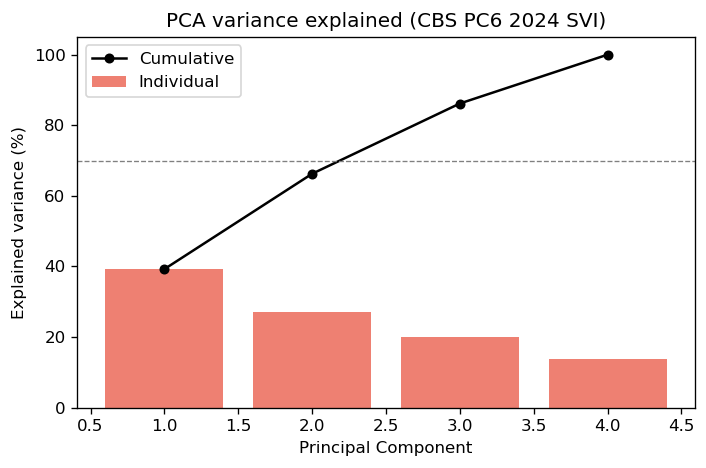

PC1: 39.2%, PC1+PC2: 66.3%


In [8]:
# Fill NaN with median before PCA, standardize, run PCA
svi_matrix = svi_df[svi_available].fillna(svi_df[svi_available].median())
scaler = StandardScaler()
svi_scaled = scaler.fit_transform(svi_matrix)
pca = PCA(n_components=len(svi_available))
pca_scores = pca.fit_transform(svi_scaled)

fig, ax = plt.subplots(figsize=(6, 4))
cumvar = np.cumsum(pca.explained_variance_ratio_)
ax.bar(range(1, len(svi_available)+1), pca.explained_variance_ratio_ * 100, color="#E84B37", alpha=0.7, label="Individual")
ax.plot(range(1, len(svi_available)+1), cumvar * 100, "k-o", markersize=5, label="Cumulative")
ax.axhline(70, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained variance (%)")
ax.set_title("PCA variance explained (CBS PC6 2024 SVI)")
ax.legend()
plt.tight_layout()
plt.savefig("output_03_pca_variance.png", bbox_inches="tight")
plt.show()
print(f"PC1: {pca.explained_variance_ratio_[0]*100:.1f}%, PC1+PC2: {cumvar[1]*100:.1f}%")


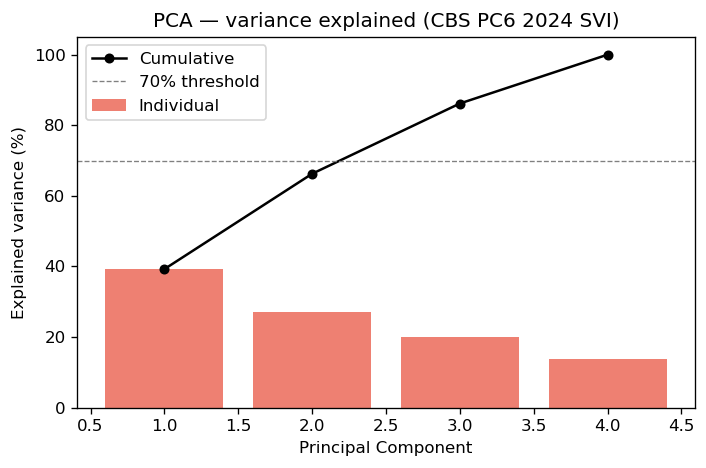

PC1 explains 39.2% of variance
PC1+PC2 explain 66.3% of variance


In [9]:
# Fill remaining NaN with median before PCA
svi_matrix = svi_df[svi_available].fillna(svi_df[svi_available].median())

# Standardize (PCA requires zero mean, unit variance)
scaler = StandardScaler()
svi_scaled = scaler.fit_transform(svi_matrix)

# Run PCA
pca = PCA(n_components=len(svi_available))
pca_scores = pca.fit_transform(svi_scaled)

# Explained variance plot
fig, ax = plt.subplots(figsize=(6, 4))
cumvar = np.cumsum(pca.explained_variance_ratio_)
ax.bar(range(1, len(svi_available)+1), pca.explained_variance_ratio_ * 100, color='#E84B37', alpha=0.7, label='Individual')
ax.plot(range(1, len(svi_available)+1), cumvar * 100, 'k-o', markersize=5, label='Cumulative')
ax.axhline(70, color='gray', linestyle='--', linewidth=0.8, label='70% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained variance (%)')
ax.set_title('PCA — variance explained (CBS PC6 2024 SVI)')
ax.legend()
plt.tight_layout()
plt.savefig('output_03_pca_variance.png', bbox_inches='tight')
plt.show()

print(f"PC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance")
print(f"PC1+PC2 explain {cumvar[1]*100:.1f}% of variance")

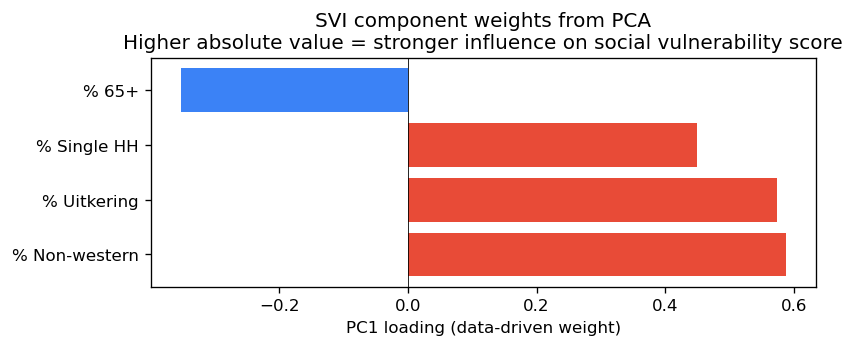

           feature  PC1_loading
  pct_niet_westers     0.587030
     pct_uitkering     0.573389
pct_eenpersoons_hh     0.449739
        pct_65plus    -0.352640


In [10]:
loadings = pd.DataFrame({
    'feature': svi_available,
    'PC1_loading': pca.components_[0]
}).sort_values('PC1_loading', key=abs, ascending=False)

short_names = {
    'pct_eenpersoons_hh': '% Single HH',
    'pct_uitkering':      '% Uitkering',
    'pct_65plus':         '% 65+',
    'pct_niet_westers':   '% Non-western',
}

fig, ax = plt.subplots(figsize=(7, 3))
colors = ['#E84B37' if v > 0 else '#3B82F6' for v in loadings['PC1_loading']]
ax.barh(range(len(loadings)), loadings['PC1_loading'], color=colors)
ax.set_yticks(range(len(loadings)))
ax.set_yticklabels([short_names.get(c, c) for c in loadings['feature']], fontsize=10)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('PC1 loading (data-driven weight)')
ax.set_title('SVI component weights from PCA\nHigher absolute value = stronger influence on social vulnerability score')
plt.tight_layout()
plt.savefig('output_04_pca_loadings.png', bbox_inches='tight')
plt.show()
print(loadings.to_string(index=False))

In [11]:
pc1 = pca_scores[:, 0]
# Flip sign if needed so higher = more vulnerable
# Use pct_65plus as reference: elderly should load positively with vulnerability
elderly_loading = loadings.loc[loadings['feature'] == 'pct_65plus', 'PC1_loading'].values
if len(elderly_loading) > 0 and elderly_loading[0] < 0:
    pc1 = -pc1
    print("Flipped PC1 sign so higher = more vulnerable")

svi_score = (pc1 - pc1.min()) / (pc1.max() - pc1.min())

svi_result = svi_df[['buurtnaam']].copy()
svi_result['svi_pca'] = svi_score

print(f"SVI score range: {svi_score.min():.3f} – {svi_score.max():.3f}")
print(f"Mean: {svi_score.mean():.3f}, Std: {svi_score.std():.3f}")
print(f"\nTop 10 most socially vulnerable buurten (CBS PC6 2024):")
print(svi_result.nlargest(10, 'svi_pca').to_string(index=False))

Flipped PC1 sign so higher = more vulnerable
SVI score range: 0.000 – 1.000
Mean: 0.736, Std: 0.108

Top 10 most socially vulnerable buurten (CBS PC6 2024):
                buurtnaam  svi_pca
         Aetsveldsepolder 1.000000
          Buiksloterbreek 0.985977
                Holysloot 0.985722
              Gaasperplas 0.985022
               Zunderdorp 0.982776
         Harmoniehofbuurt 0.979370
                Durgerdam 0.970253
Sportpark Middenmeer Zuid 0.965388
      Schellingwoude West 0.949506
           Aetsveld Noord 0.944353


## 3. Cooling Access Score

**Approach:** Combine existing CBS distance-to-amenity variables as a proxy for cooling infrastructure access. This gives an immediately usable score without requiring external network analysis data.

Components:
- `bibliotheekGemiddeldeAfstandInKm` — library (key cooling shelter type in Amsterdam)
- `zwembadGemiddeldeAfstandInKm` — swimming pool
- `treinstationGemiddeldeAfstandInKm` — transit access (ability to reach cooling spots by public transport)
- `ndvi_mean` — local green cooling potential (parks, trees)
- `water_prc` — proximity to water surfaces

**Scoring logic:** Invert distance variables (closer = better access). Normalize all to 0-1, then average. Higher score = better cooling access.

In [12]:
COOLING_FEATURES = {
    'bibliotheekGemiddeldeAfstandInKm': 'distance',   # lower = better → invert
    'zwembadGemiddeldeAfstandInKm':     'distance',
    'treinstationGemiddeldeAfstandInKm':'distance',
    'ndvi_mean':                        'positive',   # higher = better → keep
    'water_prc':                        'positive',
}

cooling_df = joined[['buurtnaam'] + list(COOLING_FEATURES.keys())].copy()
cooling_df = cooling_df.dropna(subset=list(COOLING_FEATURES.keys()), thresh=3)

scaler01 = MinMaxScaler()
normalized = {}

for col, direction in COOLING_FEATURES.items():
    if col not in cooling_df.columns:
        continue
    vals = cooling_df[col].fillna(cooling_df[col].median()).values.reshape(-1, 1)
    norm = scaler01.fit_transform(vals).flatten()
    if direction == 'distance':
        norm = 1 - norm   # invert: shorter distance = higher score
    normalized[col] = norm

cooling_df['cooling_access'] = np.mean([normalized[c] for c in normalized], axis=0)

print(f"Cooling access score computed for {len(cooling_df)} neighborhoods")
print(f"Range: {cooling_df['cooling_access'].min():.3f} – {cooling_df['cooling_access'].max():.3f}")
print("\nTop 10 best-served (highest cooling access):")
print(cooling_df.nlargest(10, 'cooling_access')[['buurtnaam', 'cooling_access']].to_string(index=False))
print("\nBottom 10 worst-served (lowest cooling access):")
print(cooling_df.nsmallest(10, 'cooling_access')[['buurtnaam', 'cooling_access']].to_string(index=False))

Cooling access score computed for 476 neighborhoods
Range: 0.000 – 0.844

Top 10 best-served (highest cooling access):
                 buurtnaam  cooling_access
    Nieuwendammerdijk Zuid        0.843580
           Vondelpark West        0.813942
               Beatrixpark        0.800069
              Bretten West        0.791028
              Buiteneiland        0.787072
              Bretten Oost        0.785349
Nieuwe Oosterbegraafplaats        0.782213
           Vondelpark Oost        0.779779
      Schellingwoude Noord        0.775935
        Noorderstrook Oost        0.768717

Bottom 10 worst-served (lowest cooling access):
                  buurtnaam  cooling_access
                KNSM-eiland    3.600000e-08
                Java-eiland    2.507512e-02
               NDSM terrein    4.889875e-02
   Coenhaven/Mercuriushaven    5.167557e-02
           Oosterdokseiland    5.463546e-02
           Nieuwe Kerk e0o0    5.701757e-02
Bedrijvengebied Cruquiusweg    5.776509e-02
       

## 4. Enhanced Heat Vulnerability Index (HVI)

| Component | Source | Weight |
|---|---|---|
| Physical heat risk | `HI_TOTAAL_S` (klimaatrisicokaarten) | 40% |
| Social vulnerability | PCA score (CBS PC6 2024) | 40% |
| Cooling access gap | 1 − cooling access score | 20% |

In [13]:
master = joined[['buurtnaam', 'HI_TOTAAL_S', 'HI_BLOOTSTELLING_S',
                  'HI_GEVOELIGHEID_S', 'HI_AANPASSINGSVERMOGEN_S']].copy()

master = master.merge(svi_result, on='buurtnaam', how='left')
master = master.merge(cooling_df[['buurtnaam', 'cooling_access']], on='buurtnaam', how='left')

hi_vals = master['HI_TOTAAL_S'].fillna(master['HI_TOTAAL_S'].median())
master['hi_norm'] = (hi_vals - hi_vals.min()) / (hi_vals.max() - hi_vals.min())
master['cooling_gap'] = 1 - master['cooling_access'].fillna(0.5)

W_HEAT = 0.40
W_SOCIAL = 0.40
W_ACCESS = 0.20

master['hvi'] = (
    W_HEAT   * master['hi_norm'].fillna(master['hi_norm'].median()) +
    W_SOCIAL * master['svi_pca'].fillna(master['svi_pca'].median()) +
    W_ACCESS * master['cooling_gap']
)
master['hvi_tier'] = pd.qcut(master['hvi'], q=5, labels=[1, 2, 3, 4, 5])

print(f"HVI computed for {master['hvi'].notna().sum()} neighbourhoods")
print(f"Score range: {master['hvi'].min():.3f} – {master['hvi'].max():.3f}")
print("\nTier distribution:")
print(master['hvi_tier'].value_counts().sort_index())

HVI computed for 498 neighbourhoods
Score range: 0.339 – 0.881

Tier distribution:
hvi_tier
1    100
2     99
3    100
4     99
5    100
Name: count, dtype: int64


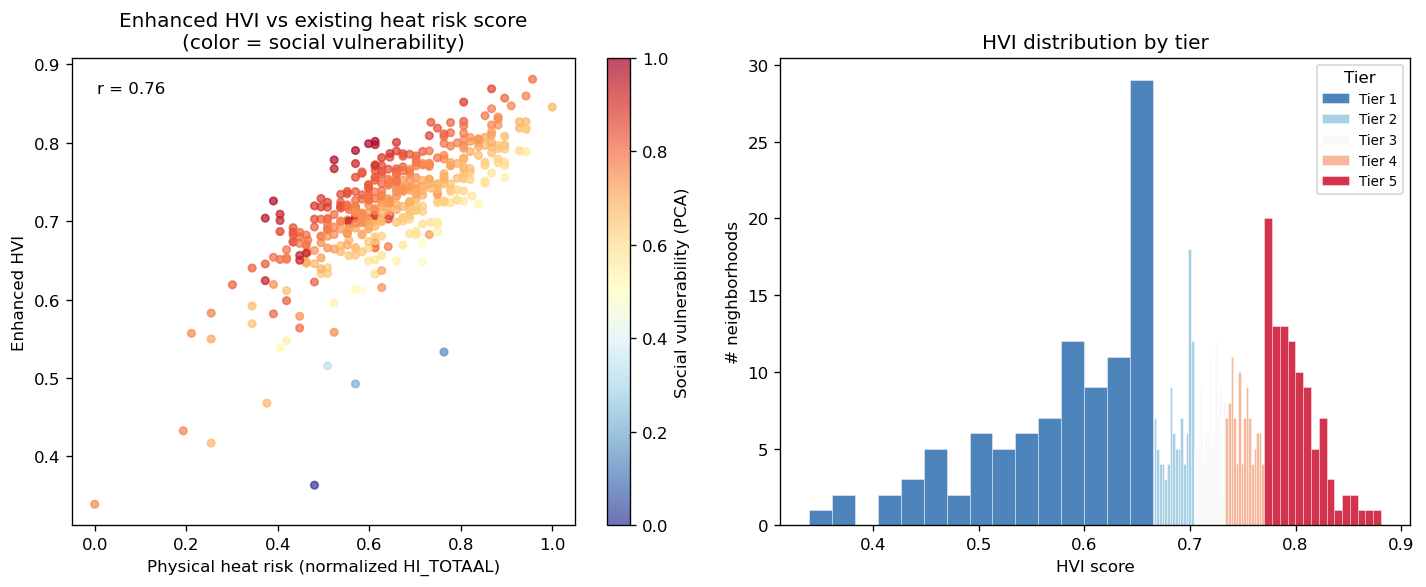

In [14]:
# How does our HVI correlate with the existing HI_TOTAAL?
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter: HI_TOTAAL vs HVI
ax = axes[0]
scatter_df = master.dropna(subset=['hi_norm', 'hvi', 'svi_pca'])
sc = ax.scatter(scatter_df['hi_norm'], scatter_df['hvi'],
                c=scatter_df['svi_pca'], cmap='RdYlBu_r', alpha=0.7, s=20)
plt.colorbar(sc, ax=ax, label='Social vulnerability (PCA)')
ax.set_xlabel('Physical heat risk (normalized HI_TOTAAL)')
ax.set_ylabel('Enhanced HVI')
ax.set_title('Enhanced HVI vs existing heat risk score\n(color = social vulnerability)')
corr_val = scatter_df[['hi_norm', 'hvi']].corr().iloc[0, 1]
ax.text(0.05, 0.95, f'r = {corr_val:.2f}', transform=ax.transAxes, va='top')

# Distribution of HVI by tier
ax = axes[1]
tier_colors = ['#2166AC', '#92C5DE', '#F7F7F7', '#F4A582', '#CA0020']
for tier, color in zip([1, 2, 3, 4, 5], tier_colors):
    subset = master[master['hvi_tier'] == tier]['hvi']
    ax.hist(subset, bins=15, color=color, alpha=0.8, label=f'Tier {tier}', edgecolor='white', linewidth=0.3)
ax.set_xlabel('HVI score')
ax.set_ylabel('# neighborhoods')
ax.set_title('HVI distribution by tier')
ax.legend(title='Tier', fontsize=8)

plt.tight_layout()
plt.savefig('output_05_hvi_overview.png', bbox_inches='tight')
plt.show()

## 5. Gap Analysis

**Core policy question:** Where are vulnerable people AND underserved by cooling infrastructure?

Cross-tabulate HVI (high/low) × cooling access (good/poor) to identify four quadrants:
- 🔴 **High vulnerability + Poor access** → Urgent intervention priority
- 🟠 **High vulnerability + Good access** → Monitor; infrastructure present but people still at risk
- 🟡 **Low vulnerability + Poor access** → Lower priority; less vulnerable population
- 🟢 **Low vulnerability + Good access** → No action needed

In [15]:
# Binary classification: top half vs bottom half for each dimension
hvi_median = master['hvi'].median()
access_median = master['cooling_access'].median()

master['hvi_high'] = master['hvi'] >= hvi_median
master['access_poor'] = master['cooling_access'] < access_median

# Quadrant labels
def quadrant_label(row):
    if row['hvi_high'] and row['access_poor']:
        return '🔴 High risk + Poor access'
    elif row['hvi_high'] and not row['access_poor']:
        return '🟠 High risk + Good access'
    elif not row['hvi_high'] and row['access_poor']:
        return '🟡 Low risk + Poor access'
    else:
        return '🟢 Low risk + Good access'

master['quadrant'] = master.apply(quadrant_label, axis=1)

print("Gap analysis — neighborhood counts per quadrant:")
print(master['quadrant'].value_counts().to_string())

# Priority neighborhoods
priority = master[master['quadrant'] == '🔴 High risk + Poor access'].copy()
priority = priority.sort_values('hvi', ascending=False)
print(f"\nTop 20 priority neighborhoods (high vulnerability + poor access):")
print(priority[['buurtnaam', 'hvi', 'hi_norm', 'svi_pca', 'cooling_access']].head(20).to_string(index=False))

Gap analysis — neighborhood counts per quadrant:
quadrant
🟢 Low risk + Good access     152
🔴 High risk + Poor access    141
🟠 High risk + Good access    108
🟡 Low risk + Poor access      97

Top 20 priority neighborhoods (high vulnerability + poor access):
                     buurtnaam      hvi  hi_norm  svi_pca  cooling_access
        Olympisch Stadion e0o0 0.880858 0.956989 0.798305        0.106299
      Tuindorp Nieuwendam West 0.851737 0.806452 0.884780        0.123779
              Haveneiland Oost 0.847032 0.910394 0.763837        0.113300
                     Overhoeks 0.843241 0.867384 0.776853        0.072266
                   Blauwe Zand 0.834385 0.853047 0.786683        0.107536
               Spuistraat Zuid 0.832691 0.881720 0.748655        0.097293
     Middelveldsche Akerpolder 0.830113 0.881720 0.753531        0.119937
              Balboaplein e0o0 0.826770 0.942652 0.681501        0.114458
                   Borgerbuurt 0.826753 0.928315 0.689818        0.102499
   

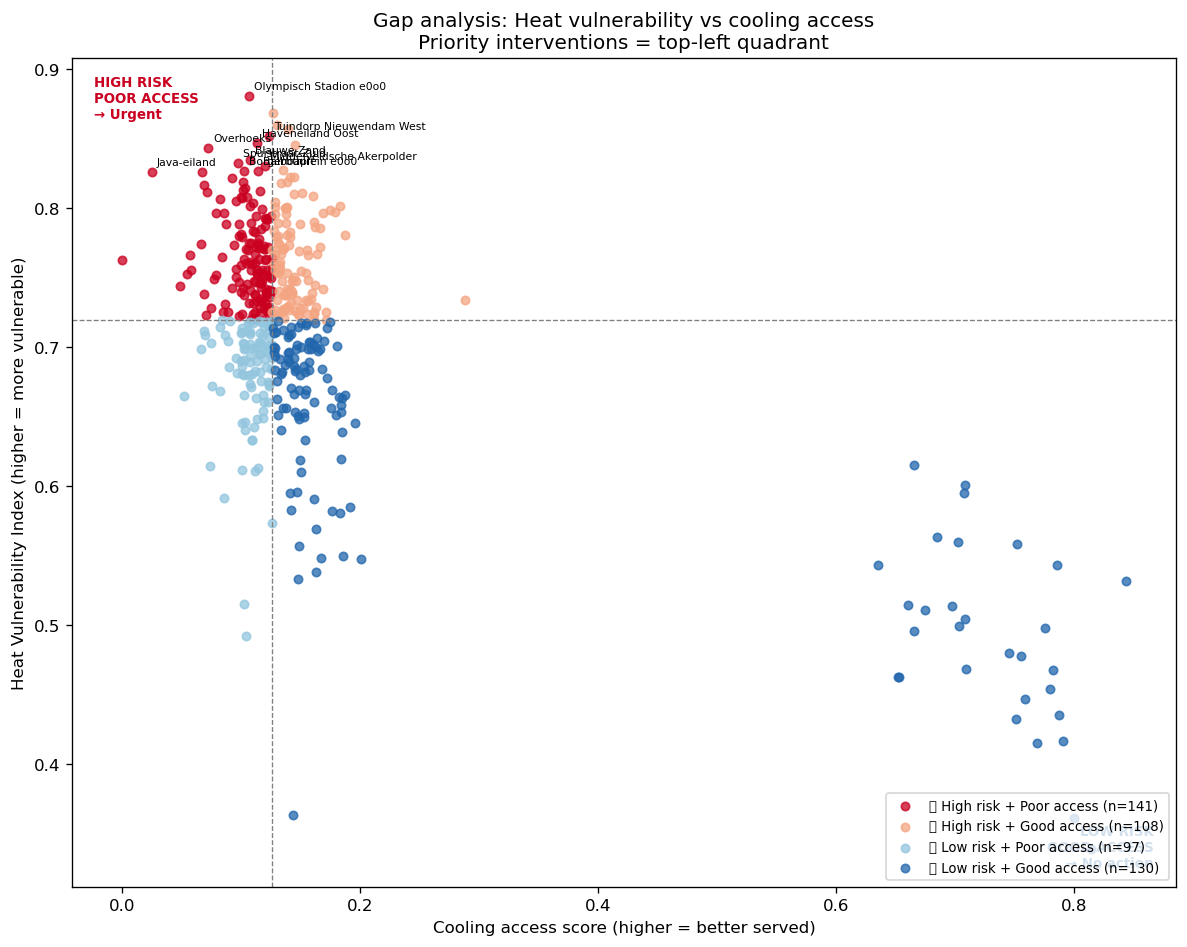

In [16]:
# Scatter plot: HVI vs cooling access (the gap map in chart form)
fig, ax = plt.subplots(figsize=(10, 8))

quadrant_colors = {
    '🔴 High risk + Poor access':  '#CA0020',
    '🟠 High risk + Good access':  '#F4A582',
    '🟡 Low risk + Poor access':   '#92C5DE',
    '🟢 Low risk + Good access':   '#2166AC',
}

plot_df = master.dropna(subset=['hvi', 'cooling_access'])
for quad, color in quadrant_colors.items():
    sub = plot_df[plot_df['quadrant'] == quad]
    ax.scatter(sub['cooling_access'], sub['hvi'], color=color, alpha=0.75, s=25, label=f'{quad} (n={len(sub)})')

# Label top 10 priority neighborhoods
for _, row in priority.head(10).iterrows():
    if pd.notna(row['cooling_access']) and pd.notna(row['hvi']):
        ax.annotate(row['buurtnaam'], (row['cooling_access'], row['hvi']),
                    fontsize=6.5, ha='left', va='bottom',
                    xytext=(3, 3), textcoords='offset points')

ax.axvline(access_median, color='gray', linestyle='--', linewidth=0.8)
ax.axhline(hvi_median, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Cooling access score (higher = better served)')
ax.set_ylabel('Heat Vulnerability Index (higher = more vulnerable)')
ax.set_title('Gap analysis: Heat vulnerability vs cooling access\nPriority interventions = top-left quadrant')
ax.legend(loc='lower right', fontsize=8)

# Quadrant labels
ax.text(0.02, 0.98, 'HIGH RISK\nPOOR ACCESS\n→ Urgent', transform=ax.transAxes,
        va='top', ha='left', fontsize=8, color='#CA0020', fontweight='bold')
ax.text(0.98, 0.02, 'LOW RISK\nGOOD ACCESS\n→ No action', transform=ax.transAxes,
        va='bottom', ha='right', fontsize=8, color='#2166AC', fontweight='bold')

plt.tight_layout()
plt.savefig('output_06_gap_analysis.png', bbox_inches='tight')
plt.show()

## 6. Spatial Autocorrelation (Moran's I + LISA)

**Why spatial stats?**
A neighborhood-by-neighborhood map of HVI scores shows variation but doesn't tell us which clusters are *statistically significant*. LISA (Local Indicators of Spatial Association) identifies:
- **High-High (HH):** High-risk neighborhood surrounded by high-risk neighbors → confirmed hotspot
- **Low-Low (LL):** Low-risk area → cold spot
- **High-Low / Low-High:** Spatial outliers — may indicate data anomalies or a boundary effect

Global Moran's I tests whether heat vulnerability is spatially clustered (expected: yes, positively clustered — vulnerable neighborhoods tend to be near each other).

In [17]:
if not SPATIAL_STATS:
    print("Skipping spatial autocorrelation — install esda and libpysal first:")
    print("  pip install esda libpysal")
else:
    from esda.moran import Moran, Moran_Local
    from libpysal.weights import Queen

    # Use only scored polygons for spatial stats
    spatial_df = gdf_joined[['buurtnaam', 'geometry']].merge(
        master[['buurtnaam', 'hvi', 'hvi_tier', 'quadrant']],
        on='buurtnaam', how='inner'
    ).dropna(subset=['hvi'])
    spatial_df = spatial_df[spatial_df.geometry.is_valid].copy()
    spatial_df = spatial_df.reset_index(drop=True)

    print(f"Spatial analysis on {len(spatial_df)} scored neighborhoods")

    if len(spatial_df) < 3:
        print("Not enough geometries for spatial weights — skipping LISA")
        SPATIAL_STATS = False
    else:
        w = Queen.from_dataframe(spatial_df, silence_warnings=True)
        w.transform = 'r'
        print(f"Spatial weights: {w.n} units, {w.mean_neighbors:.1f} avg neighbors")

Spatial analysis on 498 scored neighborhoods


Spatial weights: 498 units, 6.1 avg neighbors


Global Moran's I test
Moran's I statistic: 0.2150
Expected I (random): -0.0020
p-value (999 permutations): 0.0010

✓ Statistically significant positive spatial autocorrelation (p < 0.05)
  Vulnerable neighborhoods tend to cluster together.


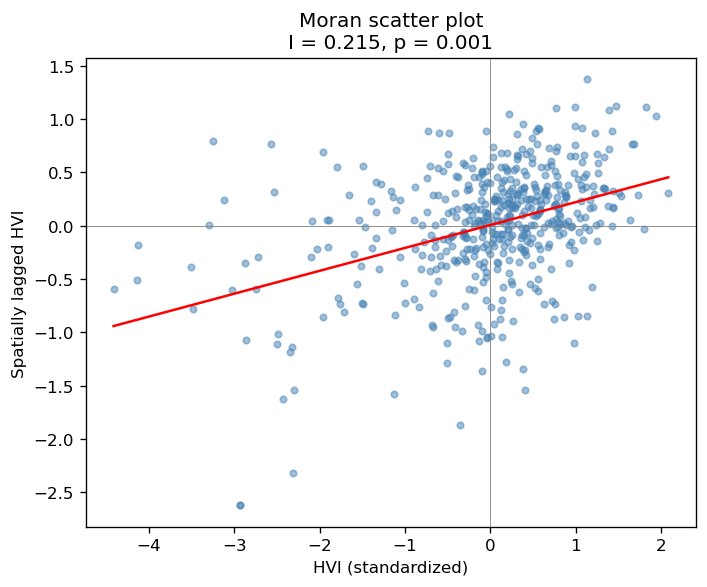

In [18]:
if SPATIAL_STATS:
    # Global Moran's I
    y = spatial_df['hvi'].values
    mi = Moran(y, w, permutations=999)

    print("=" * 50)
    print("Global Moran's I test")
    print("=" * 50)
    print(f"Moran's I statistic: {mi.I:.4f}")
    print(f"Expected I (random): {mi.EI:.4f}")
    print(f"p-value (999 permutations): {mi.p_sim:.4f}")
    print()
    if mi.p_sim < 0.05:
        direction = 'positive' if mi.I > 0 else 'negative'
        print(f"✓ Statistically significant {direction} spatial autocorrelation (p < 0.05)")
        if mi.I > 0:
            print("  Vulnerable neighborhoods tend to cluster together.")
    else:
        print("No significant spatial clustering detected.")

    # Moran scatter plot
    fig, ax = plt.subplots(figsize=(6, 5))
    z = (y - y.mean()) / y.std()
    wz = [sum(w.weights[i][j] * z[w.neighbors[i][j]] for j in range(len(w.neighbors[i]))) for i in range(len(z))]
    ax.scatter(z, wz, alpha=0.5, s=15, color='steelblue')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    m, b = np.polyfit(z, wz, 1)
    xr = np.linspace(z.min(), z.max(), 100)
    ax.plot(xr, m * xr + b, 'r-', linewidth=1.5)
    ax.set_xlabel('HVI (standardized)')
    ax.set_ylabel('Spatially lagged HVI')
    ax.set_title(f"Moran scatter plot\nI = {mi.I:.3f}, p = {mi.p_sim:.3f}")
    plt.tight_layout()
    plt.savefig('output_07_moran_scatter.png', bbox_inches='tight')
    plt.show()

LISA cluster counts:
Not significant    395
HH (hotspot)        40
LL (cold spot)      35
HL (outlier)        16
LH (outlier)        12


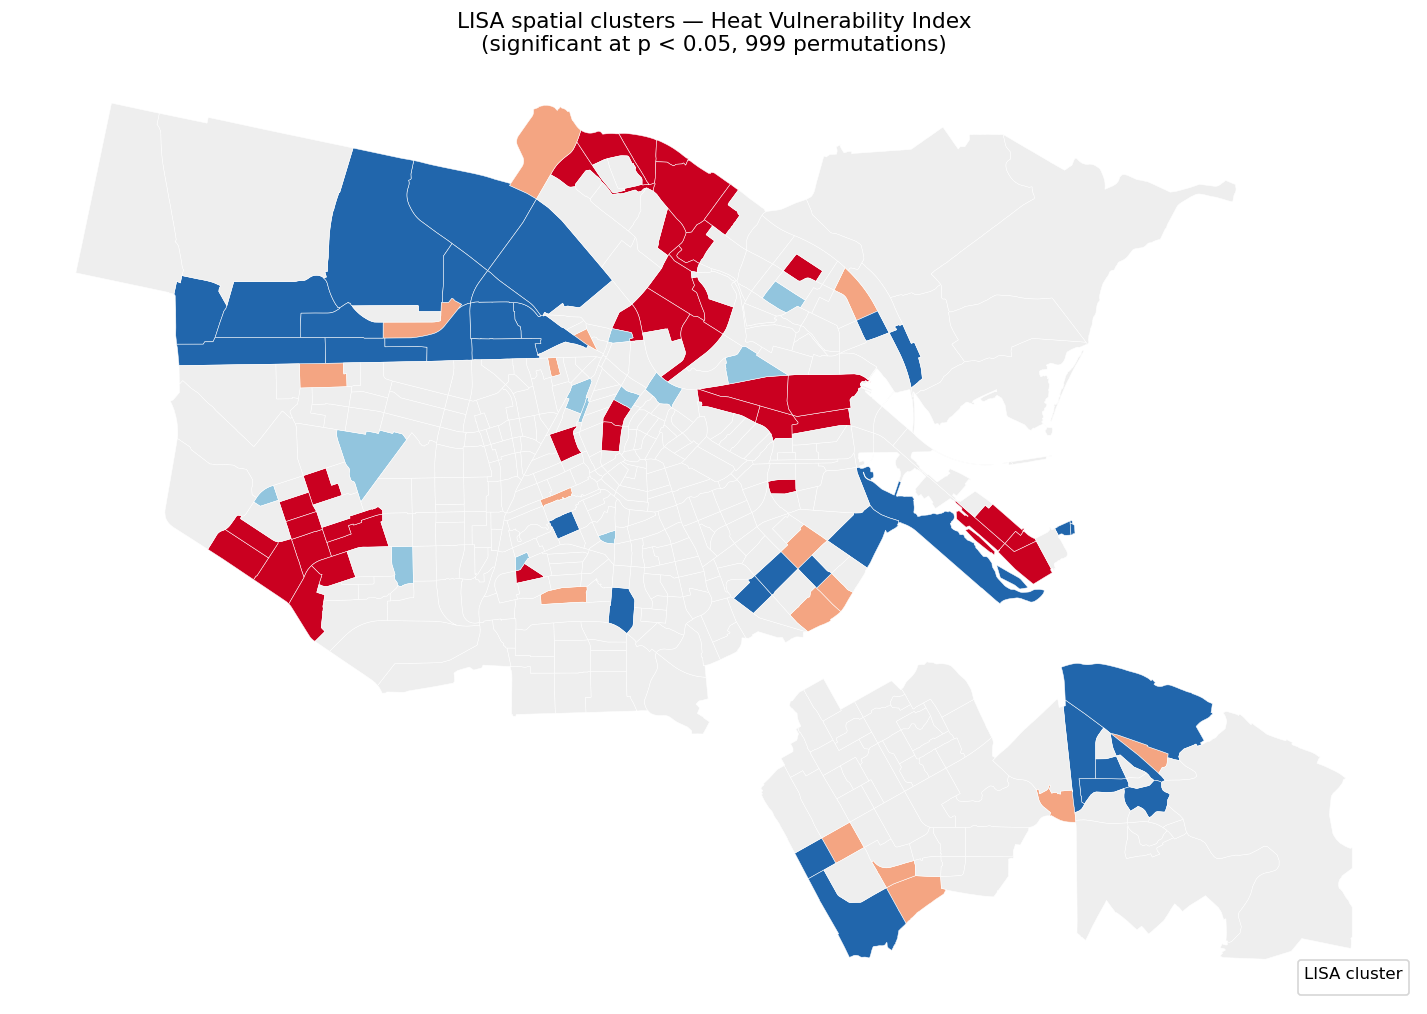


Hotspot neighborhoods (HH):
  Banne Noordwest
  Banne Zuidwest
  Bloemenbuurt Zuid
  Buiksloterbreek
  Buiksloterham
  Calandlaan/Lelylaan
  Da Costabuurt Noord
  De Aker Oost
  De Aker West
  De Bongerd
  De Kleine Wereld
  Dorp Sloten
  Felix Meritisbuurt
  Haveneiland Noord
  Haveneiland Noordoost
  Haveneiland Oost
  Haveneiland Zuidwest/Rieteiland West
  Houthavens Oost
  Java-eiland
  KNSM-eiland
  Kadoelen
  Leliegracht e0o0
  Marathonbuurt West
  Middelveldsche Akerpolder
  Nieuw Sloten Noordwest
  Noordwestkwadrant Indische buurt Zuid
  Oostelijke Handelskade
  Oostzanerdijk
  Osdorp Midden Zuid
  Osdorp Zuidoost
  Papaverweg e0o0
  Rietlanden
  Sporenburg
  Twiske Oost
  Twiske West
  Van der Pekbuurt
  Walvisbuurt
  Wildeman
  Zuidwestkwadrant Osdorp Noord
  Zuidwestkwadrant Osdorp Zuid


In [19]:
if SPATIAL_STATS:
    # Local Moran's I (LISA)
    lisa = Moran_Local(y, w, permutations=999)

    # Classify LISA cluster types
    sig = lisa.p_sim < 0.05
    spot_labels = np.full(len(spatial_df), 'Not significant', dtype=object)
    spot_labels[(lisa.q == 1) & sig] = 'HH (hotspot)'
    spot_labels[(lisa.q == 2) & sig] = 'LH (outlier)'
    spot_labels[(lisa.q == 3) & sig] = 'LL (cold spot)'
    spot_labels[(lisa.q == 4) & sig] = 'HL (outlier)'

    spatial_df['lisa_cluster'] = spot_labels
    spatial_df['lisa_p'] = lisa.p_sim
    spatial_df['lisa_I'] = lisa.Is

    print("LISA cluster counts:")
    print(pd.Series(spot_labels).value_counts().to_string())

    # Map LISA clusters
    cluster_colors = {
        'HH (hotspot)':  '#CA0020',
        'HL (outlier)':  '#F4A582',
        'LH (outlier)':  '#92C5DE',
        'LL (cold spot)':'#2166AC',
        'Not significant': '#EEEEEE',
    }

    fig, ax = plt.subplots(figsize=(12, 10))
    for cluster, color in cluster_colors.items():
        subset = spatial_df[spatial_df['lisa_cluster'] == cluster]
        if len(subset) > 0:
            subset.plot(ax=ax, color=color, edgecolor='white', linewidth=0.3,
                        label=f'{cluster} (n={len(subset)})')

    ax.set_title('LISA spatial clusters — Heat Vulnerability Index\n(significant at p < 0.05, 999 permutations)',
                 fontsize=13)
    ax.legend(loc='lower right', fontsize=9, title='LISA cluster')
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig('output_08_lisa_map.png', bbox_inches='tight', dpi=150)
    plt.show()

    print("\nHotspot neighborhoods (HH):")
    hh_buurten = spatial_df[spatial_df['lisa_cluster'] == 'HH (hotspot)']['buurtnaam'].tolist()
    for b in sorted(hh_buurten):
        print(f"  {b}")

## 7. Priority neighborhood ranking

Combine gap analysis (urgent quadrant) + LISA hotspot status into a final priority list for policy makers.

In [20]:
# Build priority table
priority_df = master[['buurtnaam', 'hvi', 'hi_norm', 'svi_pca', 'cooling_access', 'quadrant']].copy()
priority_df = priority_df.sort_values('hvi', ascending=False)

# Add LISA cluster if computed
if SPATIAL_STATS and 'lisa_cluster' in spatial_df.columns:
    priority_df = priority_df.merge(
        spatial_df[['buurtnaam', 'lisa_cluster']],
        on='buurtnaam', how='left'
    )
    priority_df['lisa_cluster'] = priority_df['lisa_cluster'].fillna('Not computed')
    # Flag confirmed hotspots
    priority_df['confirmed_hotspot'] = priority_df['lisa_cluster'] == 'HH (hotspot)'

# Top 20 by HVI in the priority quadrant
urgent = priority_df[
    priority_df['quadrant'] == '🔴 High risk + Poor access'
].head(20)

print("TOP 20 PRIORITY NEIGHBORHOODS FOR INTERVENTION")
print("(High vulnerability + Poor cooling access, ranked by HVI)")
print("=" * 90)

display_cols = ['buurtnaam', 'hvi', 'hi_norm', 'svi_pca', 'cooling_access']
if 'confirmed_hotspot' in urgent.columns:
    display_cols.append('confirmed_hotspot')

print(urgent[display_cols].rename(columns={
    'buurtnaam': 'Neighborhood',
    'hvi': 'HVI score',
    'hi_norm': 'Physical heat',
    'svi_pca': 'Social vuln.',
    'cooling_access': 'Cooling access',
    'confirmed_hotspot': 'LISA hotspot'
}).to_string(index=False))

TOP 20 PRIORITY NEIGHBORHOODS FOR INTERVENTION
(High vulnerability + Poor cooling access, ranked by HVI)
                  Neighborhood  HVI score  Physical heat  Social vuln.  Cooling access  LISA hotspot
        Olympisch Stadion e0o0   0.880858       0.956989      0.798305        0.106299         False
      Tuindorp Nieuwendam West   0.851737       0.806452      0.884780        0.123779         False
              Haveneiland Oost   0.847032       0.910394      0.763837        0.113300          True
                     Overhoeks   0.843241       0.867384      0.776853        0.072266         False
                   Blauwe Zand   0.834385       0.853047      0.786683        0.107536         False
               Spuistraat Zuid   0.832691       0.881720      0.748655        0.097293         False
     Middelveldsche Akerpolder   0.830113       0.881720      0.753531        0.119937          True
              Balboaplein e0o0   0.826770       0.942652      0.681501        0.114458 

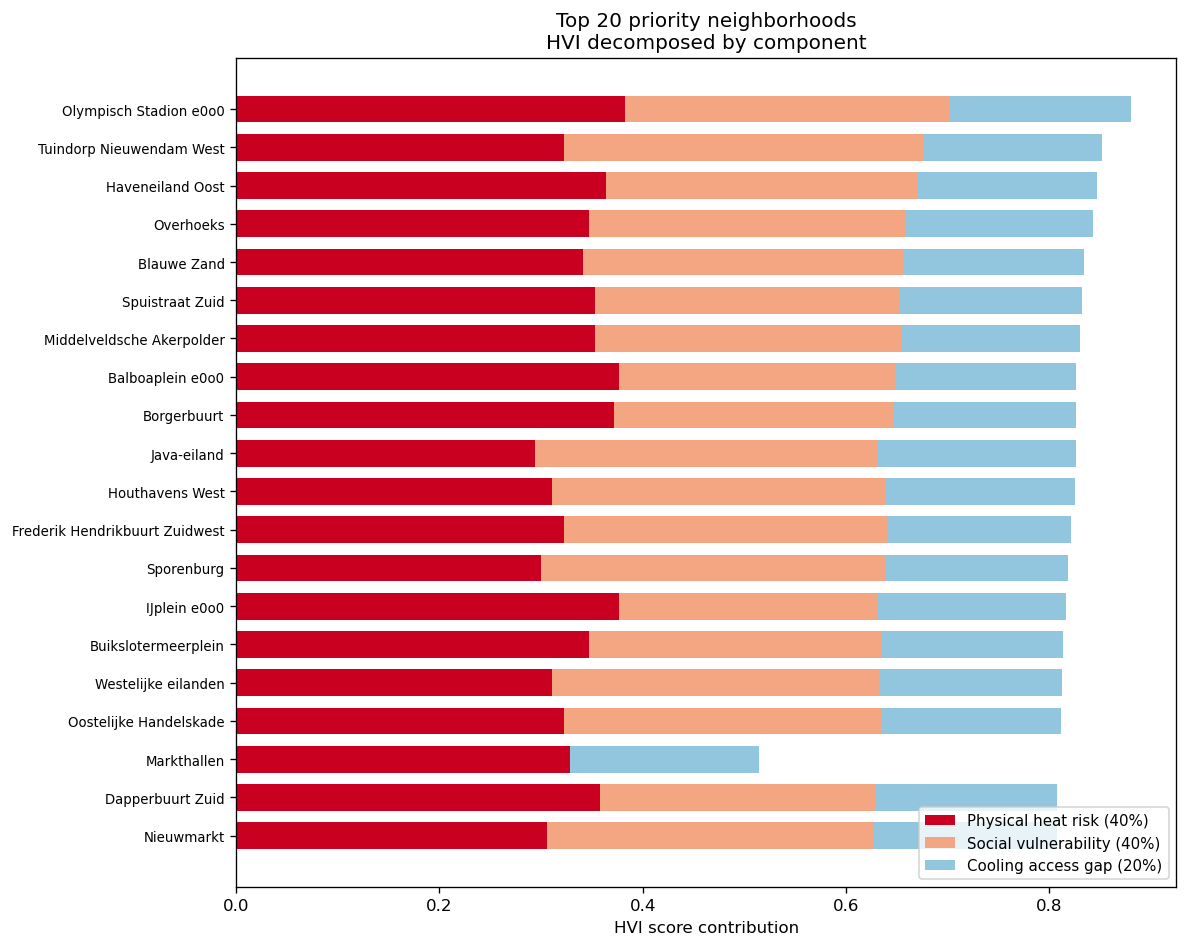

In [21]:
# Bar chart of top 20 — decomposed by component
plot_data = urgent.head(20).copy()
plot_data = plot_data.sort_values('hvi')

fig, ax = plt.subplots(figsize=(10, 8))

bar_width = 0.7
y_pos = range(len(plot_data))

# Stacked bar: physical + social + cooling gap components
physical_contrib = W_HEAT * plot_data['hi_norm'].fillna(0)
social_contrib   = W_SOCIAL * plot_data['svi_pca'].fillna(0)
access_contrib   = W_ACCESS * (1 - plot_data['cooling_access'].fillna(0.5))

ax.barh(y_pos, physical_contrib, bar_width, label='Physical heat risk (40%)', color='#CA0020')
ax.barh(y_pos, social_contrib, bar_width, left=physical_contrib, label='Social vulnerability (40%)', color='#F4A582')
ax.barh(y_pos, access_contrib, bar_width,
        left=physical_contrib + social_contrib, label='Cooling access gap (20%)', color='#92C5DE')

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_data['buurtnaam'], fontsize=8)
ax.set_xlabel('HVI score contribution')
ax.set_title('Top 20 priority neighborhoods\nHVI decomposed by component')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('output_09_priority_ranking.png', bbox_inches='tight')
plt.show()

## 8. Map visualizations

Choropleth maps for the two policy products:
1. **HVI map** — continuous vulnerability surface with tier overlay
2. **Gap map** — four-quadrant action map

Map dataframe: 498 rows, 498 with HVI scores


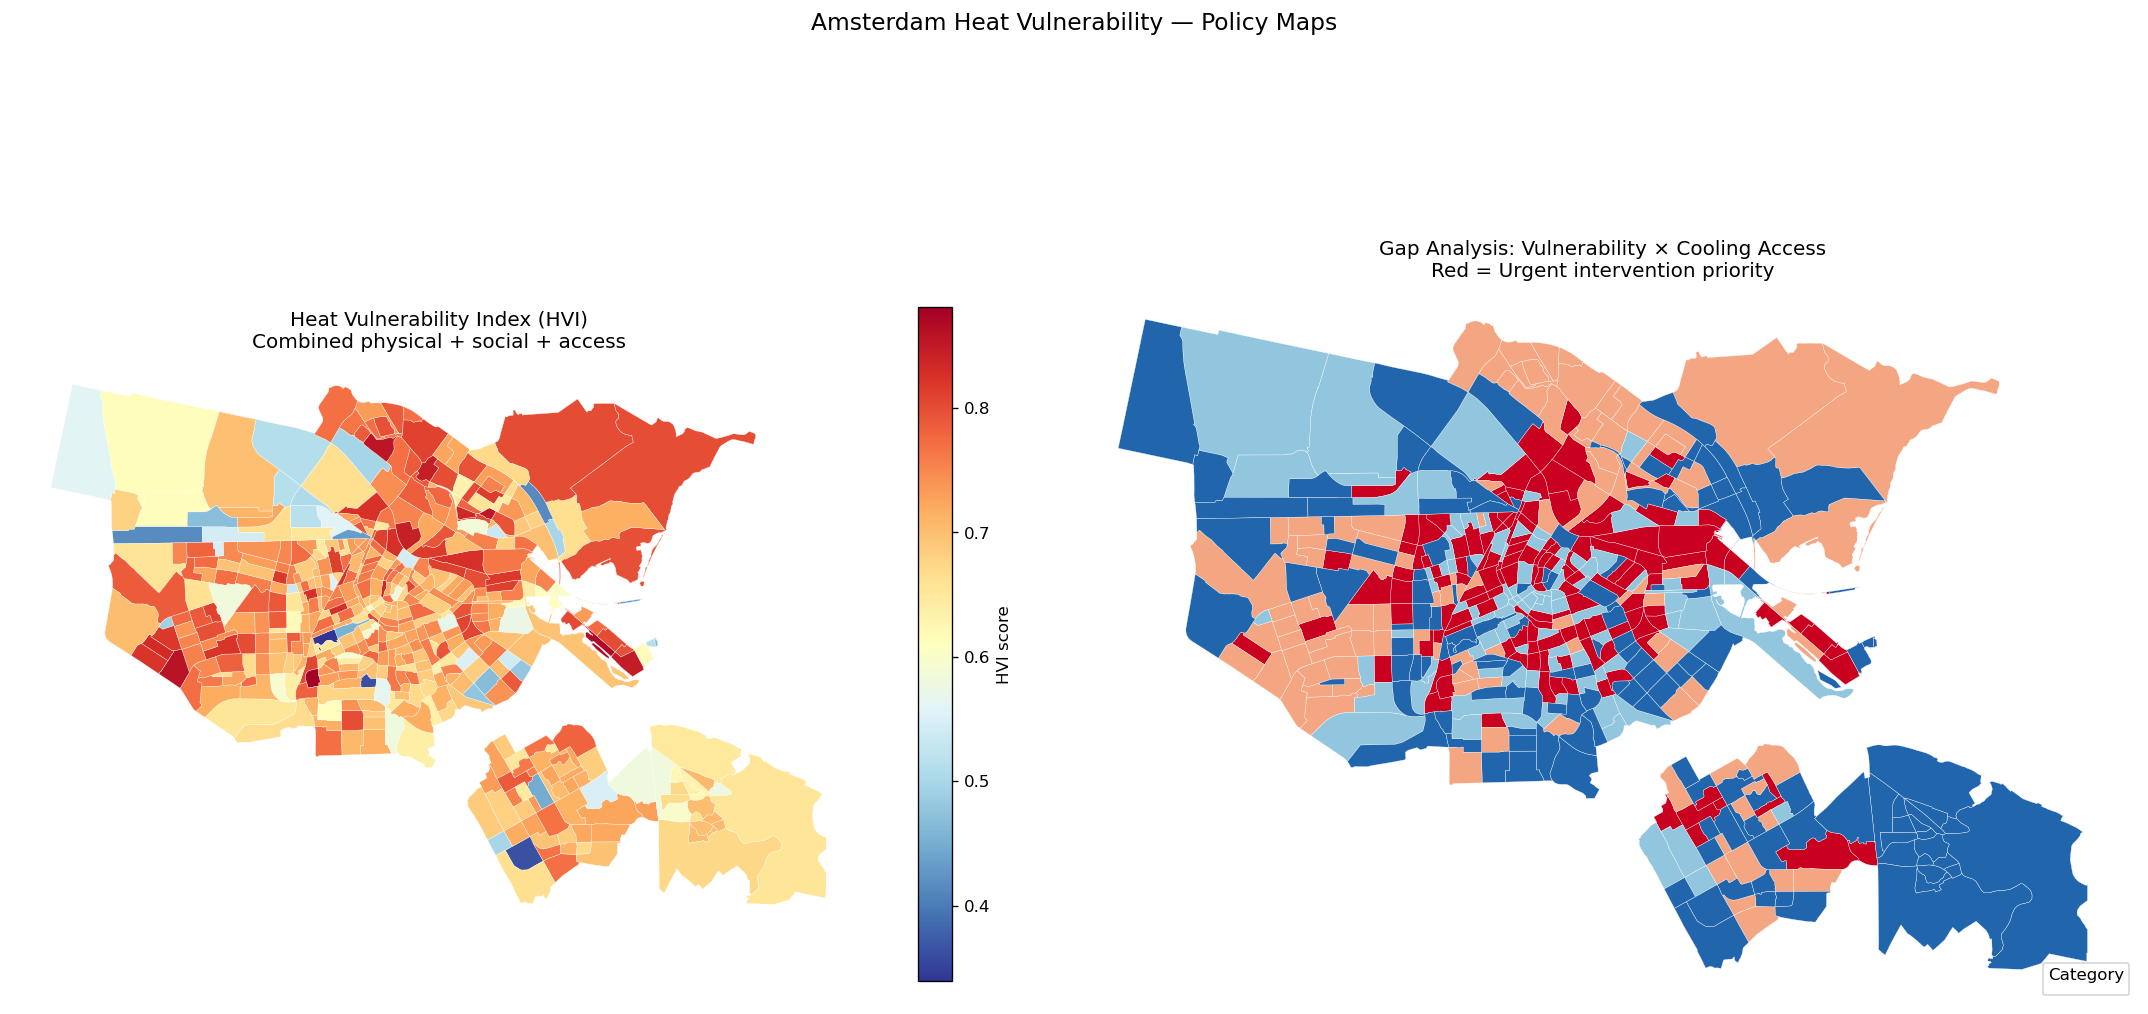

In [22]:
# Merge all scores onto geometry for mapping
map_df = gdf_joined[['buurtnaam', 'geometry']].merge(
    master[['buurtnaam', 'hvi', 'hvi_tier', 'hi_norm', 'svi_pca', 'cooling_access', 'quadrant']],
    on='buurtnaam', how='left'
)

print(f"Map dataframe: {len(map_df)} rows, {map_df['hvi'].notna().sum()} with HVI scores")

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Map 1: HVI choropleth
ax = axes[0]
map_df.plot(column='hvi', cmap='RdYlBu_r', legend=True, ax=ax,
            edgecolor='white', linewidth=0.2, missing_kwds={'color': '#CCCCCC'},
            legend_kwds={'label': 'HVI score', 'orientation': 'vertical', 'shrink': 0.6})
ax.set_title('Heat Vulnerability Index (HVI)\nCombined physical + social + access', fontsize=12)
ax.set_axis_off()

# Map 2: Gap analysis quadrants
ax = axes[1]
quad_color_map = {
    '🔴 High risk + Poor access':  '#CA0020',
    '🟠 High risk + Good access':  '#F4A582',
    '🟡 Low risk + Poor access':   '#92C5DE',
    '🟢 Low risk + Good access':   '#2166AC',
}
for quad, color in quad_color_map.items():
    subset = map_df[map_df['quadrant'] == quad]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, edgecolor='white', linewidth=0.2,
                    label=quad.split(' ', 1)[1])

missing_quad = map_df[map_df['quadrant'].isna()]
if len(missing_quad) > 0:
    missing_quad.plot(ax=ax, color='#CCCCCC', edgecolor='white', linewidth=0.2)

ax.set_title('Gap Analysis: Vulnerability × Cooling Access\nRed = Urgent intervention priority', fontsize=12)
ax.legend(loc='lower right', fontsize=8, title='Category')
ax.set_axis_off()

plt.suptitle('Amsterdam Heat Vulnerability — Policy Maps', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('output_10_policy_maps.png', bbox_inches='tight', dpi=150)
plt.show()

In [23]:
import os
os.makedirs('outputs', exist_ok=True)

# --- CSV: all scores ---
export_cols = ['buurtnaam', 'hvi', 'hvi_tier', 'hi_norm', 'svi_pca',
               'cooling_access', 'cooling_gap', 'quadrant',
               'HI_TOTAAL_S', 'HI_BLOOTSTELLING_S', 'HI_GEVOELIGHEID_S']
export_cols = [c for c in export_cols if c in master.columns]
master[export_cols].to_csv('outputs/hvi_scores.csv', index=False)
print("Saved: outputs/hvi_scores.csv")

# --- CSV: priority neighbourhoods ---
priority_export = priority_df[
    priority_df['quadrant'] == '🔴 High risk + Poor access'
].head(20)[['buurtnaam', 'hvi', 'hi_norm', 'svi_pca', 'cooling_access']]
priority_export.to_csv('outputs/priority_neighborhoods.csv', index=False)
print("Saved: outputs/priority_neighborhoods.csv")

# --- GeoJSON: map-ready ---
geo_keep = ['buurtnaam', 'hvi', 'hvi_tier', 'hi_norm', 'svi_pca',
            'cooling_access', 'quadrant', 'geometry']
if SPATIAL_STATS and 'lisa_cluster' in spatial_df.columns:
    map_df = map_df.merge(spatial_df[['buurtnaam', 'lisa_cluster', 'lisa_p']],
                          on='buurtnaam', how='left')
    geo_keep += ['lisa_cluster']

geo_keep = [c for c in geo_keep if c in map_df.columns]
export_gdf = map_df[geo_keep].copy()
if 'hvi_tier' in export_gdf.columns:
    export_gdf['hvi_tier'] = export_gdf['hvi_tier'].astype(str)
if export_gdf.crs and export_gdf.crs.to_epsg() != 4326:
    export_gdf = export_gdf.to_crs(epsg=4326)

export_gdf.to_file('outputs/hvi_map.geojson', driver='GeoJSON')
print("Saved: outputs/hvi_map.geojson")
print(f"\n{len(export_gdf)} polygons, {export_gdf['hvi'].notna().sum()} with HVI scores")

Saved: outputs/hvi_scores.csv
Saved: outputs/priority_neighborhoods.csv


Saved: outputs/hvi_map.geojson

498 polygons, 498 with HVI scores


## 10. What's next

### Data gaps to fill (in priority order)

| Gap | What to add | Why it matters |
|---|---|---|
| **Single-person elderly** | CBS maatwerk: `eenpersoonshuishoudens_65plus` per buurt | Strongest predictor of heat mortality; currently using all single-person households as proxy |
| **Klimaateffectatlas full data** | Add when available | Can replace/validate our physical heat composite |
| **Cooling shelter capacity + hours** | Add opening hours and capacity to koelteplekken.csv | A library closed at 5pm doesn't help during a weekend heatwave |
| **GTFS transit data (GVB)** | Route + schedule data for realistic transit isochrones | Improves cooling access score from CBS proxy to actual travel time |
| **Health outcome validation** | GGD ambulance call or excess mortality data per buurt | Validates HVI against real outcomes — essential for policy credibility |

### Analysis extensions
- **Temporal coverage layer:** What % of heatwave hours (typically 10:00–18:00) is each neighborhood covered by an open cooling spot?
- **Scenario modeling:** If we add N cooling spots in the top 5 priority areas, how many vulnerable residents gain access?
- **Two-step floating catchment area (2SFCA):** Model supply (cooling spot capacity) vs demand (vulnerable population density) once capacity data is available
- **Sensitivity analysis:** Re-run HVI with W_HEAT ±0.1 to test how robust the priority ranking is to weight choices